In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s6e4/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e4/train.csv
/kaggle/input/competitions/playground-series-s6e4/test.csv


In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score
from sklearn.inspection import permutation_importance
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/train.csv')
test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/test.csv')

print(train.shape, test.shape)
print(train['Irrigation_Need'].value_counts(normalize=True))

(630000, 21) (270000, 20)
Irrigation_Need
Low       0.587170
Medium    0.379483
High      0.033348
Name: proportion, dtype: float64


In [4]:
# Check for nulls and data types
print(train.isnull().sum())
print("\n")
print(train.dtypes)

id                         0
Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64


id                           int64
Soil_Type                   object
Soil_pH                    float64
Soil_Moisture              float64
Organic_Carbon             float64
Electrical_Conductivity    float64
Temperature_C              float64
Humidity                   float64
Rainfall_mm                float64
Sunlight_Hours             float64
Wind_Speed_kmh            

In [5]:
# Define target and drop id
X = train.drop(columns=['id', 'Irrigation_Need'])
y = train['Irrigation_Need']

# Encode categoricals
cat_cols = X.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)

X = pd.get_dummies(X, columns=cat_cols)
test_processed = pd.get_dummies(test.drop(columns=['id']), columns=cat_cols)

# Align columns in case test is missing any
X, test_processed = X.align(test_processed, join='left', axis=1, fill_value=0)

print("Train shape:", X.shape)
print("Test shape:", test_processed.shape)

Categorical columns: ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']
Train shape: (630000, 43)
Test shape: (270000, 43)


In [6]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Class balance in val:", y_val.value_counts(normalize=True).round(3))

Train: (504000, 43)
Val: (126000, 43)
Class balance in val: Irrigation_Need
Low       0.587
Medium    0.379
High      0.033
Name: proportion, dtype: float64


In [7]:
# Interaction and ratio features
for df in [X_train, X_val, test_processed]:
    df['Temp_Humidity_interaction'] = df['Temperature_C'] * df['Humidity']
    df['Rainfall_per_SunHour'] = df['Rainfall_mm'] / (df['Sunlight_Hours'] + 1)
    df['Moisture_Carbon_ratio'] = df['Soil_Moisture'] / (df['Organic_Carbon'] + 1)
    df['Wind_Humidity_interaction'] = df['Wind_Speed_kmh'] * df['Humidity']
    df['Prev_Irrigation_per_Area'] = df['Previous_Irrigation_mm'] / (df['Field_Area_hectare'] + 1)

print("New shape:", X_train.shape)
print("New features added:", 5)

New shape: (504000, 48)
New features added: 5


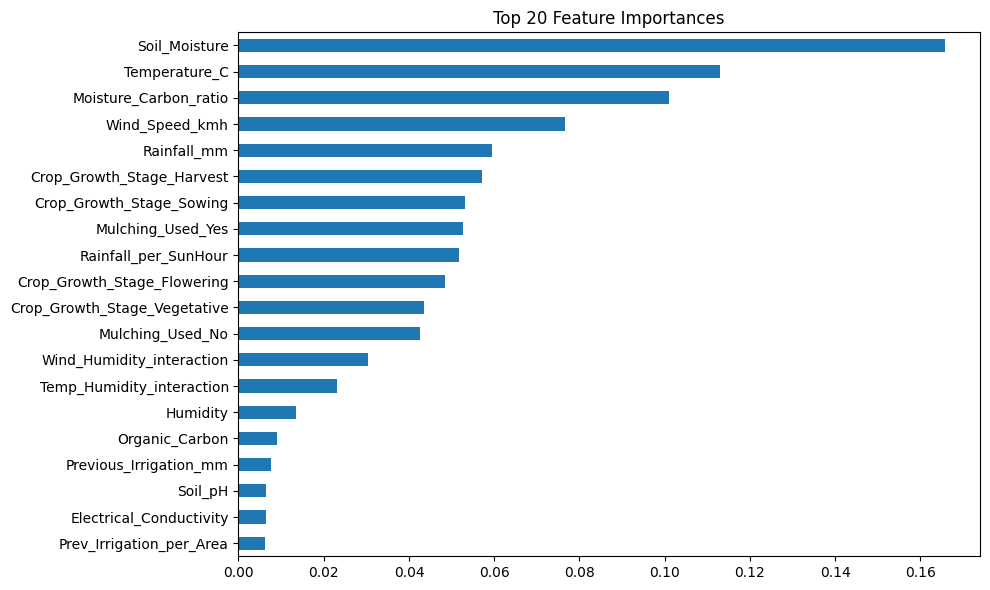

Quick RF Balanced Accuracy: 0.9611


In [8]:
# Quick RF to get feature importances
from sklearn.ensemble import RandomForestClassifier

rf_quick = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf_quick.fit(X_train, y_train)

# Plot top 20 features
importances = pd.Series(rf_quick.feature_importances_, index=X_train.columns)
top20 = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
top20.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 20 Feature Importances')
plt.tight_layout()
plt.show()

# Quick score
from sklearn.metrics import balanced_accuracy_score
y_pred_quick = rf_quick.predict(X_val)
print("Quick RF Balanced Accuracy:", balanced_accuracy_score(y_val, y_pred_quick).round(4))

In [9]:
from sklearn.preprocessing import LabelEncoder

# Encode target labels
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)

print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

neg = (y_train_enc != le.transform(['High'])[0]).sum()
pos = (y_train_enc == le.transform(['High'])[0]).sum()
scale = neg / pos

# Random Forest
rf = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                             max_depth=20, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train_enc)
rf_score = balanced_accuracy_score(y_val_enc, rf.predict(X_val))
print("RF Balanced Accuracy:", round(rf_score, 4))

# XGBoost
xgb_model = xgb.XGBClassifier(n_estimators=300, scale_pos_weight=scale,
                                learning_rate=0.05, max_depth=6,
                                random_state=42, eval_metric='mlogloss', n_jobs=-1)
xgb_model.fit(X_train, y_train_enc)
xgb_score = balanced_accuracy_score(y_val_enc, xgb_model.predict(X_val))
print("XGB Balanced Accuracy:", round(xgb_score, 4))

# LightGBM
lgb_model = lgb.LGBMClassifier(n_estimators=300, is_unbalance=True,
                                 learning_rate=0.05, max_depth=6,
                                 random_state=42, n_jobs=-1)
lgb_model.fit(X_train, y_train_enc)
lgb_score = balanced_accuracy_score(y_val_enc, lgb_model.predict(X_val))
print("LGB Balanced Accuracy:", round(lgb_score, 4))

Label mapping: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}
RF Balanced Accuracy: 0.9628
XGB Balanced Accuracy: 0.965
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.053742 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4001
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 48
[LightGBM] [Info] Start training from score -3.400781
[LightGBM] [Info] Start training from score -0.532440
[LightGBM] [Info] Start training from score -0.968948
LGB Balanced Accuracy: 0.9649


In [10]:
# Probability averaging ensemble (faster, often just as good as stacking)
rf_probs = rf.predict_proba(X_val)
xgb_probs = xgb_model.predict_proba(X_val)
lgb_probs = lgb_model.predict_proba(X_val)

# Equal weight average
avg_probs = (rf_probs + xgb_probs + lgb_probs) / 3
avg_preds = avg_probs.argmax(axis=1)

ensemble_score = balanced_accuracy_score(y_val_enc, avg_preds)
print("Ensemble (avg) Balanced Accuracy:", round(ensemble_score, 4))

Ensemble (avg) Balanced Accuracy: 0.9654


In [11]:
# Predict on test set
rf_test = rf.predict_proba(test_processed)
xgb_test = xgb_model.predict_proba(test_processed)
lgb_test = lgb_model.predict_proba(test_processed)

# Average probabilities
avg_test = (rf_test + xgb_test + lgb_test) / 3
test_preds = avg_test.argmax(axis=1)

# Decode back to original labels
test_preds_labels = le.inverse_transform(test_preds)

# Build submission
submission = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/sample_submission.csv')
submission['Irrigation_Need'] = test_preds_labels
submission.to_csv('submission.csv', index=False)

print(submission['Irrigation_Need'].value_counts())
print(submission.head())

Irrigation_Need
Low       159849
Medium    101529
High        8622
Name: count, dtype: int64
       id Irrigation_Need
0  630000             Low
1  630001             Low
2  630002             Low
3  630003             Low
4  630004             Low
